<a href="https://colab.research.google.com/github/betulbilhan2/LLM-Augmentation-Fidelity/blob/main/NB01_Data_and_Split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01: Data Initialization, Cleaning, EDA, and Leakage-Free Splitting

**Goal:**
1. Mount Google Drive for persistent storage across different Colab accounts.
2. Initialize the exact folder structure required for the 10-notebook pipeline.
3. Save the global experiment configuration (`experiment_config.yaml`).
4. Load the Winvoker Turkish Sentiment dataset.
5. Create a fixed, quarantined Validation and Test set (to prevent data leakage).
6. Generate 10 distinct `train` splits for both `low` (10/class) and `normal` (100/class) resource levels using 10 different random seeds.
7. Perform basic Exploratory Data Analysis (EDA) with IEEE-compliant plots.


In [ ]:
# Install necessary packages (if not already installed)
!pip install pyyaml pandas matplotlib seaborn scikit-learn datasets

import os
import sys
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import logging
from datetime import datetime

# Define a global run timestamp for versioning artifacts
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# Mount Google Drive to save data persistently
from google.colab import drive
drive.mount('/content/drive')

# Define the root directory in Google Drive
PROJECT_ROOT = '/content/drive/MyDrive/tr_augmentation_project'
os.makedirs(PROJECT_ROOT, exist_ok=True)
print(f"Project root set to: {PROJECT_ROOT}")


Mounted at /content/drive
Project root set to: /content/drive/MyDrive/tr_augmentation_project


In [ ]:
# Define and create the folder structure defined in the pipeline plan
directories = [
    "00_raw",
    "01_splits/fixed",
    "01_splits/low",
    "01_splits/normal",
    "02_augmented/low/duplication_control",
    "02_augmented/low/backtranslation",
    "02_augmented/low/llm_paraphrase",
    "02_augmented/normal/duplication_control",
    "02_augmented/normal/backtranslation",
    "02_augmented/normal/llm_paraphrase",
    "03_quality/low/similarity",
    "03_quality/low/duplicates",
    "03_quality/low/leakage",
    "03_quality/low/label_consistency",
    "03_quality/normal/similarity",
    "03_quality/normal/duplicates",
    "03_quality/normal/leakage",
    "04_filtered/low/backtranslation",
    "04_filtered/low/llm_paraphrase",
    "04_filtered/normal/backtranslation",
    "04_filtered/normal/llm_paraphrase",
    "05_balanced/low/backtranslation",
    "05_balanced/low/llm_paraphrase",
    "05_balanced/normal/backtranslation",
    "05_balanced/normal/llm_paraphrase",
    "06_embeddings/low",
    "06_embeddings/normal",
    "07_diversity_metrics/low",
    "07_diversity_metrics/normal",
    "08_models/low",
    "08_models/normal",
    "09_predictions/low",
    "09_predictions/normal",
    "10_statistics/low",
    "10_statistics/normal",
    "11_figures",
    "12_tables",
    "configs",
    "logs",
    "manifests",
    "utils"
]

for seed in range(10):
    directories.append(f"01_splits/low/seed_{seed}")
    directories.append(f"01_splits/normal/seed_{seed}")

for d in directories:
    os.makedirs(os.path.join(PROJECT_ROOT, d), exist_ok=True)

# Setup logging
log_file_path = os.path.join(PROJECT_ROOT, "logs", "nb01_run.log")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file_path, encoding='utf-8'),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

logger.info("Directory structure successfully created in Google Drive.")


In [ ]:
# Define the experiment configuration based on the final protocol
experiment_config = {
    "dataset": {
        "name": "winvoker/turkish-sentiment-analysis-dataset",
        "split_seed": 42
    },
    "seeds": {
        "data_seeds": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        "model_seed": 42
    },
    "resource_levels": {
        "low": {
            "size_per_class": 10,
            "sensitivity_sizes": [5, 20],
            "manual_audit": True
        },
        "normal": {
            "size_per_class": 100,
            "manual_audit": False
        }
    },
    "augmentation": {
        "target_ratio": 1.0,
        "equalize_after_filtering": True
    },
    "quality_filter": {
        "embedding_model": "emrecan/bert-base-turkish-cased-mean-nli-stsb-tr",
        "cosine_threshold": 0.70
    },
    "leakage_check": {
        "primary_criterion": ["exact_match", "normalized_match"],
        "embedding_similarity_threshold": 0.90
    },
    "model": {
        "name": "dbmdz/bert-base-turkish-cased",
        "max_length": 128
    },
    "training": {
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "early_stopping_patience": 3
    },
    "llm_augmentation": {
        "provider": "groq",
        "model": "llama3-8b-8192", # Placeholder, update before running NB03
        "temperature": 0,
        "top_p": 1.0,
        "max_tokens": 128,
        "prompt_file": "prompts/paraphrase_v1.txt"
    },
    "diversity": {
        "fsd_epsilon": 1.0e-6
    },
    "statistics": {
        "primary_test": "friedman",
        "posthoc": "wilcoxon_signed_rank",
        "correction": "holm",
        "primary_metric": "macro_f1",
        "ci_method": "bootstrap"
    }
}

config_path = os.path.join(PROJECT_ROOT, "configs", "experiment_config.yaml")
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(experiment_config, f, allow_unicode=True, sort_keys=False)

logger.info(f"Experiment configuration saved to: {config_path}")


In [ ]:
# Save utils/plotting.py for consistent IEEE style across all notebooks
plotting_code = """
import os
import subprocess
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# IEEE standard requires specific styling (e.g., Times New Roman, specific sizes)
def set_ieee_style():
    warnings.filterwarnings("ignore")

    # Safely install Times New Roman system-wide in Colab if missing
    fonts = [f.name for f in fm.fontManager.ttflist]
    if "Times New Roman" not in fonts:
        print("Downloading and installing Times New Roman fonts (one-time setup)...")
        # Accept EULA automatically and install
        subprocess.run("echo ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true | debconf-set-selections", shell=True)
        subprocess.run("apt-get install -y ttf-mscorefonts-installer -qq > /dev/null 2>&1", shell=True)

        # Manually load the newly installed fonts into matplotlib's current memory
        font_dir = "/usr/share/fonts/truetype/msttcorefonts"
        if os.path.exists(font_dir):
            for font_path in fm.findSystemFonts(fontpaths=[font_dir]):
                try:
                    fm.fontManager.addfont(font_path)
                except Exception:
                    pass

    plt.style.use(['seaborn-v0_8-paper'])
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "axes.labelsize": 10,
        "font.size": 10,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "figure.figsize": (3.5, 2.5), # standard IEEE single column width
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })

COLORS = {
    "original": "#333333",
    "duplication_control": "#7f7f7f",
    "backtranslation": "#1f77b4",
    "llm_paraphrase": "#d62728",
}

LINESTYLES = {
    "original": "-",
    "duplication_control": ":",
    "backtranslation": "--",
    "llm_paraphrase": "-.",
}
"""
utils_path = os.path.join(PROJECT_ROOT, "utils", "plotting.py")
with open(utils_path, "w", encoding="utf-8") as f:
    f.write(plotting_code)
logger.info("IEEE Plotting utilities saved with Ubuntu system font installer.")


In [ ]:
# Load the dataset from Hugging Face
logger.info("Loading dataset from Hugging Face...")
dataset = load_dataset("winvoker/turkish-sentiment-analysis-dataset")

# The dataset usually comes in a 'train' split, we'll convert it to a pandas DataFrame
df = dataset['train'].to_pandas()
logger.info(f"Initial dataset size: {len(df)}")

# Basic Cleaning
# Remove empty texts or NA
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].str.strip()
df = df[df['text'] != '']
logger.info(f"Size after basic cleaning: {len(df)}")

# Map string labels to integers if necessary. Assuming labels are strings or already ints.
# Let's check the unique labels
logger.info(f"Unique labels: {df['label'].unique()}")

# In Winvoker, labels are typically 'Negative', 'Notr', 'Positive'.
# We ensure standard mapping: 0: Negative, 1: Neutral, 2: Positive
# Note: Check your dataset's specific labels. We use a try-except to handle variations.
try:
    if df['label'].dtype == object:
        label_map = {"Negative": 0, "Notr": 1, "Positive": 2}
        df['label'] = df['label'].map(label_map)
except Exception as e:
    logger.info(f"Label mapping skipped or failed: {e}")

df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Save raw cleaned dataset
raw_path = os.path.join(PROJECT_ROOT, "00_raw", "cleaned_dataset.csv")
df.to_csv(raw_path, index=False)
logger.info("Cleaned dataset saved.")


README.md:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 76.1MB            

train.csv: downloading bytes:           |  0.00B            

test.csv:   0%|          | 0.00/8.47M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/440679 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/48965 [00:00<?, ? examples/s]

In [ ]:
# Step 1: Extract a fixed Validation and Test set (Quarantine to prevent leakage)
# These will be the exact same for ALL experiments and seeds.

SPLIT_SEED = experiment_config["dataset"]["split_seed"]

# Let's do a stratified split to ensure class balance.
# For a 490k dataset, taking 10% for testing and 10% for validation is plenty.
df_train_pool, df_temp = train_test_split(df, test_size=0.10, random_state=SPLIT_SEED, stratify=df['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=SPLIT_SEED, stratify=df_temp['label'])

logger.info(f"Validation set size: {len(df_val)}")
logger.info(f"Test set size: {len(df_test)}")
logger.info(f"Remaining Training pool size: {len(df_train_pool)}")

# Save Fixed Val and Test
fixed_split_dir = os.path.join(PROJECT_ROOT, "01_splits", "fixed")
df_val.to_csv(os.path.join(fixed_split_dir, "validation.csv"), index=False)
df_test.to_csv(os.path.join(fixed_split_dir, "test.csv"), index=False)

# Manifest to keep track of indices to prove no leakage
manifest = {
    "val_indices": df_val.index.tolist(),
    "test_indices": df_test.index.tolist(),
    "train_splits": {"low": {}, "normal": {}}
}
with open(os.path.join(fixed_split_dir, f"split_manifest_{RUN_TIMESTAMP}.json"), "w") as f:
    json.dump(manifest, f)

logger.info("Fixed Test and Validation sets quarantined and saved.")


In [ ]:
# Step 2: Generate 10 independent train splits for `low` (10/class) and `normal` (100/class)

DATA_SEEDS = experiment_config["seeds"]["data_seeds"]
LOW_SIZE = experiment_config["resource_levels"]["low"]["size_per_class"]
NORMAL_SIZE = experiment_config["resource_levels"]["normal"]["size_per_class"]
LABELS = sorted(df_train_pool['label'].unique())

for seed in DATA_SEEDS:
    low_frames = []
    normal_frames = []

    for label in LABELS:
        # Filter pool by class
        df_class_pool = df_train_pool[df_train_pool['label'] == label]

        # Sample for normal (100/class)
        # We sample independently for each seed to simulate different starting states
        sampled_normal = df_class_pool.sample(n=NORMAL_SIZE, random_state=seed)
        normal_frames.append(sampled_normal)

        # Sample for low (10/class)
        # Sample independently to maintain rigor
        sampled_low = df_class_pool.sample(n=LOW_SIZE, random_state=seed)
        low_frames.append(sampled_low)

    # Combine and shuffle
    df_train_normal = pd.concat(normal_frames).sample(frac=1, random_state=seed)
    df_train_low = pd.concat(low_frames).sample(frac=1, random_state=seed)

    # Update manifest before resetting index
    manifest["train_splits"]["normal"][f"seed_{seed}"] = df_train_normal.index.tolist()
    manifest["train_splits"]["low"][f"seed_{seed}"] = df_train_low.index.tolist()

    df_train_normal = df_train_normal.reset_index(drop=True)
    df_train_low = df_train_low.reset_index(drop=True)

    # Save splits
    df_train_normal.to_csv(os.path.join(PROJECT_ROOT, f"01_splits/normal/seed_{seed}/train_seed.csv"), index=False)
    df_train_low.to_csv(os.path.join(PROJECT_ROOT, f"01_splits/low/seed_{seed}/train_seed.csv"), index=False)

# Save the updated manifest with seed indices to the manifests directory
manifests_dir = os.path.join(PROJECT_ROOT, "manifests")
with open(os.path.join(manifests_dir, f"split_manifest_{RUN_TIMESTAMP}.json"), "w") as f:
    json.dump(manifest, f)
# Also overwrite the one in fixed split dir to keep it consistent
with open(os.path.join(fixed_split_dir, f"split_manifest_{RUN_TIMESTAMP}.json"), "w") as f:
    json.dump(manifest, f)

logger.info(f"Successfully generated 10 seed splits for both 'low' and 'normal' resource levels and recorded indices in split_manifest_{RUN_TIMESTAMP}.json.")


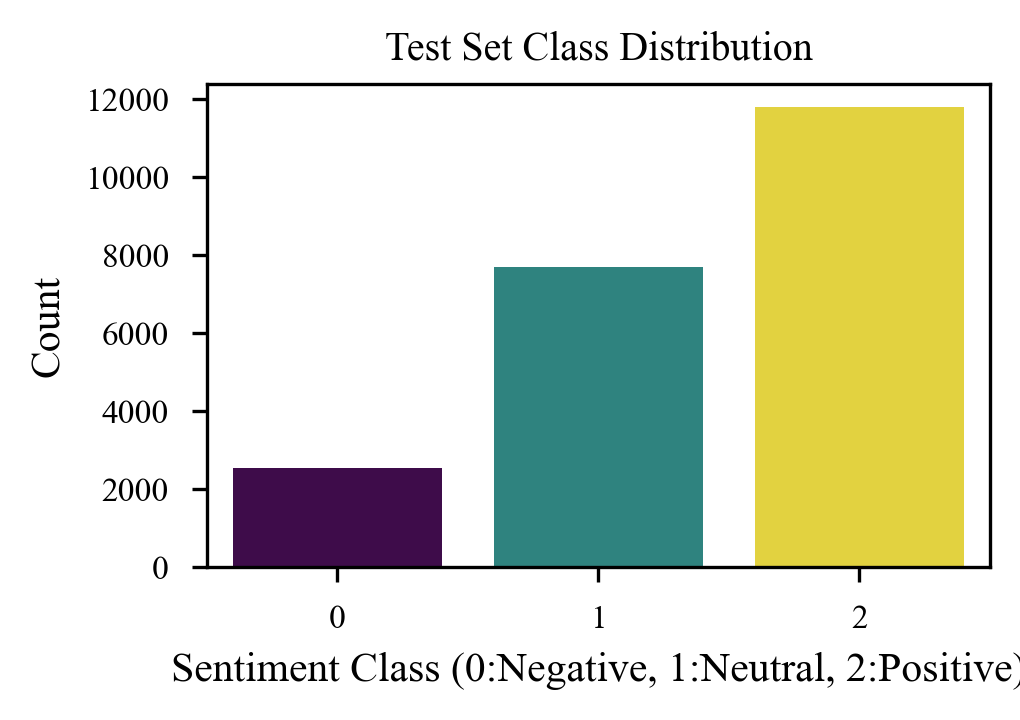

In [ ]:
# Step 3: EDA - Generate an IEEE styled plot showing the class distribution of the TEST set
import sys
sys.path.append(os.path.join(PROJECT_ROOT))
from utils.plotting import set_ieee_style
import importlib

# Force reload the plotting module to clear any cache
import utils.plotting
importlib.reload(utils.plotting)
from utils.plotting import set_ieee_style

# This will trigger the font installation safely
set_ieee_style()

plt.figure(figsize=(3.5, 2.5))
# Using 'viridis' palette which is colorblind-safe and prints distinctly in grayscale (IEEE friendly)
ax = sns.countplot(data=df_test, x='label', hue='label', palette="viridis", legend=False)
plt.title("Test Set Class Distribution")
plt.xlabel("Sentiment Class (0:Negative, 1:Neutral, 2:Positive)")
plt.ylabel("Count")

plt.tight_layout()

# Save figure for the paper
fig_path = os.path.join(PROJECT_ROOT, "11_figures", "test_set_distribution.pdf")
plt.savefig(fig_path)
plt.show()

logger.info(f"IEEE formatted figure saved to: {fig_path}")
